# Analyse exploratoire des données utiles
Données provenant des csv créés dans le fichier ``create_csv.ipynb``

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import importlib
import numpy as np

import functions_eda   # fichier python contenant les fonctions utiles à l'EDA

In [2]:
# Lecture des deux csv créés
train_audio = pd.read_csv("./eda_csv/train_audio_metadata.csv")
soundscapes = pd.read_csv("./eda_csv/soundscapes_metadata.csv")

In [3]:
train_audio.describe()

,duration
count,35549.000000
mean,34.882604
std,74.861285
min,0.008000
25%,10.788562
50%,21.000000
75%,39.837313
max,6881.097000


In [4]:
train_audio.info()

<class 'pandas.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   filename    35549 non-null  str    
 1   species_id  35549 non-null  str    
 2   duration    35549 non-null  float64
 3   filepath    35549 non-null  str    
 4   MFCC        35549 non-null  str    
dtypes: float64(1), str(4)
memory usage: 1.4 MB


In [5]:
soundscapes.describe()

,filename,filepath,MFCC
count,1478,1478,1478
unique,66,66,66
top,BC2026_Train_0039_S22_20211231_201500.ogg,data/train_soundscapes/BC2026_Train_0039_S22_2...,[-183.58652 39.8234 -103.10475 27.2...
freq,24,24,24


In [6]:
soundscapes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1478 entries, 0 to 1477
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filename  1478 non-null   str  
 1   filepath  1478 non-null   str  
 2   MFCC      1478 non-null   str  
dtypes: str(3)
memory usage: 34.8 KB


## Skewness de la durée

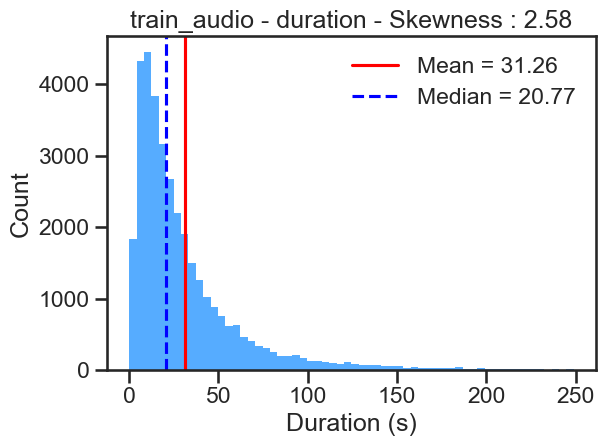

In [7]:
functions_eda.show_skewness(train_audio["duration"], "train_audio", "duration", "Duration (s)", max_value=250)  # max_value à 250 pour éliminer les outliers

## Skewness du nombre d'échantillon par espèce

Nombre d'espèces : 206


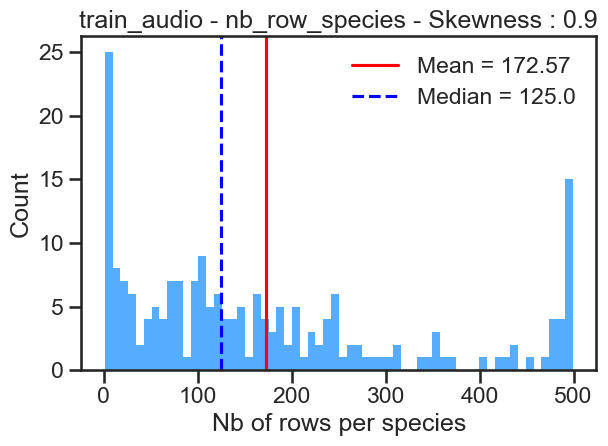

In [8]:
species = train_audio["species_id"].unique()
print("Nombre d'espèces :", len(species))
value_count_species = train_audio["species_id"].value_counts()
functions_eda.show_skewness(value_count_species, "train_audio", "nb_row_species", "Nb of rows per species")

# Étude d'un échantillon

In [9]:
# Première ligne de train_audio
first_line = train_audio.iloc[0]

audio_path = first_line["filepath"]

### Waveplot

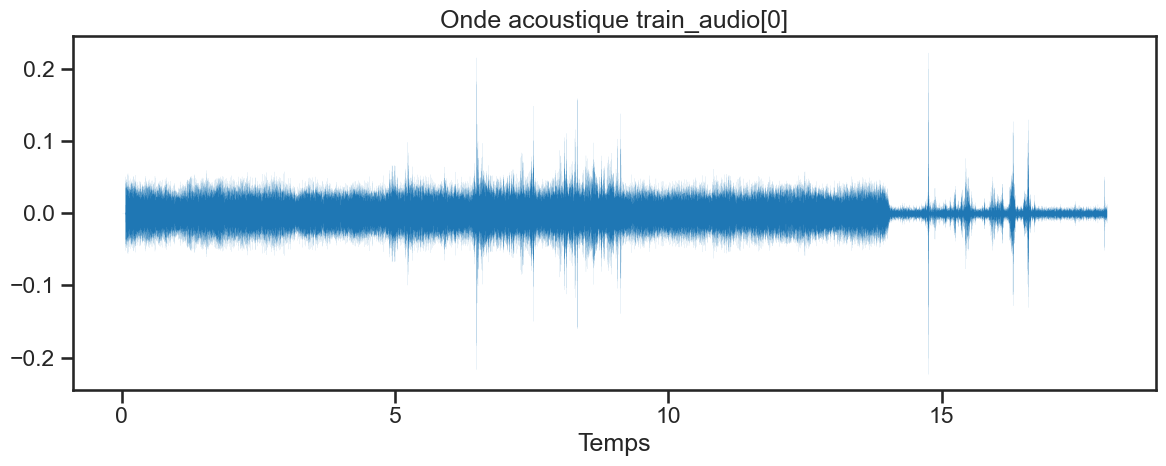

In [10]:
functions_eda.waveshow(audio_path, "train_audio[0]")

### Spectogramme

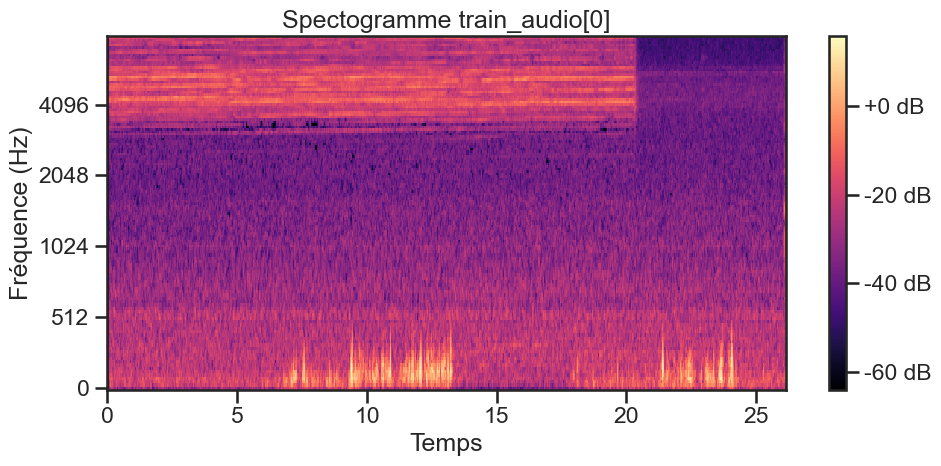

In [11]:
functions_eda.specshow(audio_path, "train_audio[0]")

### MFCC

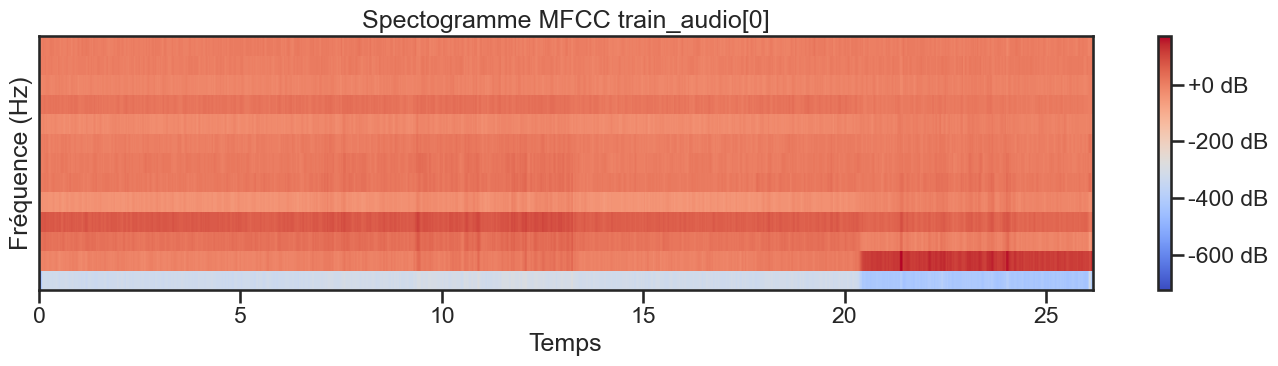

In [12]:
functions_eda.specshow_mfcc(audio_path, "train_audio[0]")